
🚀 Training with Adam...


Adam:   0%|          | 0/15 [00:00<?, ?it/s]


🚀 Training with AdamW...


AdamW:   0%|          | 0/15 [00:00<?, ?it/s]

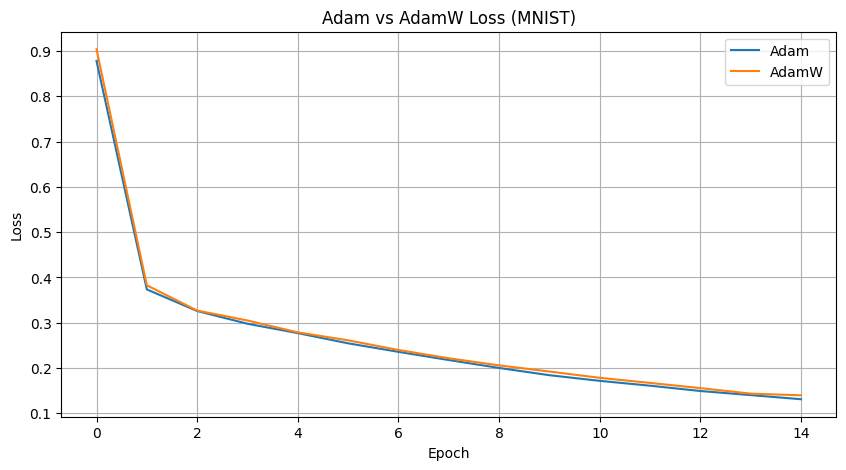


🌀 Training Autoencoder (Compression 784 -> 32)...


AE Epoch 1:   0%|          | 0/59 [00:00<?, ?it/s]

AE Loss: 0.3396


AE Epoch 2:   0%|          | 0/59 [00:00<?, ?it/s]

AE Loss: 0.1560


...

AE Loss: 0.0620


AE Epoch 9:   0%|          | 0/59 [00:00<?, ?it/s]

AE Loss: 0.0586


AE Epoch 10:   0%|          | 0/59 [00:00<?, ?it/s]

AE Loss: 0.0557

📦 Encoding datasets...

--- FINAL COMPARISON (10 Epochs) ---
📊 Original (784 dims)  | Acc: 0.8425 | Time: 0.4520s
📊 Latent (32 dims)     | Acc: 0.5168 | Time: 0.0314s


In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import time
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 1024
epochs = 15
lr = 0.001

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_set = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_set = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

class TinyMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x): return self.net(x)

def train_with_opt(opt_name):
    model = TinyMLP().to(device)
    criterion = nn.CrossEntropyLoss()
    
    if opt_name == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=lr)
    elif opt_name == 'AdamW':
        optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=0.05)
    
    losses = []
    print(f"\n🚀 Training with {opt_name}...")
    
    pbar = tqdm(range(epochs), desc=f"{opt_name}")
    for epoch in pbar:
        epoch_loss = 0
        batches_processed = 0
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            batches_processed += 1
            if batches_processed > 50: break
            
        avg_loss = epoch_loss / batches_processed
        losses.append(avg_loss)
        pbar.set_postfix({'loss': f'{avg_loss:.4f}'})
        
    return losses

# Запуск сравнения оптимизаторов
opt_results = {name: train_with_opt(name) for name in ['Adam', 'AdamW']}

plt.figure(figsize=(10, 5))
for name, loss_hist in opt_results.items():
    plt.plot(loss_hist, label=name)
plt.title("Adam vs AdamW Loss (MNIST)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# 2. АВТОЭНКОДЕР
class Autoencoder(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 784),
            nn.Tanh()
        )
    def forward(self, x):
        return self.decoder(self.encoder(x))

latent_dim = 32
ae = Autoencoder(latent_dim).to(device)
ae_optimizer = optim.Adam(ae.parameters(), lr=lr)
ae_criterion = nn.MSELoss()

print(f"\n🌀 Training Autoencoder (Compression 784 -> {latent_dim})...")
ae_epochs = 10
for epoch in range(ae_epochs):
    ae_loss = 0
    for data, _ in tqdm(train_loader, desc=f"AE Epoch {epoch+1}"):
        data = data.to(device)
        recon = ae(data)
        loss = ae_criterion(recon, data.view(-1, 784))
        
        ae_optimizer.zero_grad()
        loss.backward()
        ae_optimizer.step()
        ae_loss += loss.item()
    print(f"AE Loss: {ae_loss/len(train_loader):.4f}")

# Готовим данные для финального сравнения
def get_encoded_data(loader):
    ae.eval()
    features, labels = [], []
    with torch.no_grad():
        for data, target in loader:
            feat = ae.encoder(data.to(device))
            features.append(feat.cpu())
            labels.append(target)
    return torch.cat(features), torch.cat(labels)

print("\n📦 Encoding datasets...")
train_feat, train_labels = get_encoded_data(train_loader)
test_feat, test_labels = get_encoded_data(test_loader)

# 3. ФИНАЛЬНОЕ СРАВНЕНИЕ
def train_final_mlp(input_dim, train_data, train_lab, test_data, test_lab, name):
    # Делаем простую классификацию
    model = nn.Sequential(
        nn.Linear(input_dim, 64),
        nn.ReLU(),
        nn.Linear(64, 10)
    ).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.005)
    criterion = nn.CrossEntropyLoss()
    
    start_time = time.time()
    # Обучаем 5 эпох для сравнения скорости
    for e in range(10):
        model.train()
        optimizer.zero_grad()
        out = model(train_data.to(device))
        loss = criterion(out, train_lab.to(device))
        loss.backward()
        optimizer.step()
    
    duration = time.time() - start_time
    
    model.eval()
    with torch.no_grad():
        test_out = model(test_data.to(device))
        pred = test_out.argmax(dim=1)
        acc = (pred == test_lab.to(device)).float().mean().item()
    
    print(f"📊 {name:20} | Acc: {acc:.4f} | Time: {duration:.4f}s")

print("\n--- FINAL COMPARISON (10 Epochs) ---")
# Оригинальные данные
train_orig = train_set.data.view(-1, 784).float() / 255.0
test_orig = test_set.data.view(-1, 784).float() / 255.0

train_final_mlp(784, train_orig, train_set.targets, test_orig, test_set.targets, "Original (784 dims)")
train_final_mlp(32, train_feat, train_labels, test_feat, test_labels, f"Latent ({latent_dim} dims)")


🎨 Training 2D Latent Space Visualization...


2D AE Epoch 1:   0%|          | 0/59 [00:00<?, ?it/s]

2D AE Epoch 2:   0%|          | 0/59 [00:00<?, ?it/s]

2D AE Epoch 3:   0%|          | 0/59 [00:00<?, ?it/s]

2D AE Epoch 4:   0%|          | 0/59 [00:00<?, ?it/s]

...

2D AE Epoch 16:   0%|          | 0/59 [00:00<?, ?it/s]

2D AE Epoch 17:   0%|          | 0/59 [00:00<?, ?it/s]

2D AE Epoch 18:   0%|          | 0/59 [00:00<?, ?it/s]

2D AE Epoch 19:   0%|          | 0/59 [00:00<?, ?it/s]

2D AE Epoch 20:   0%|          | 0/59 [00:00<?, ?it/s]

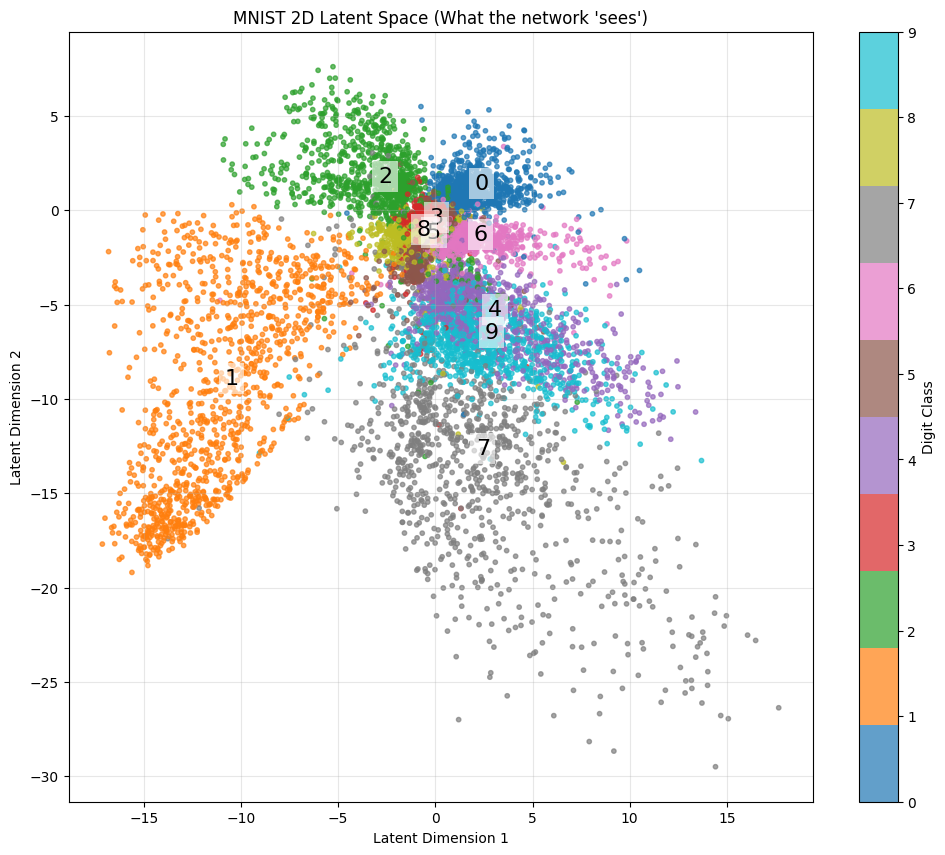

In [10]:
import numpy as np

class Autoencoder2D(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, 2)  # Всего 2 нейрона на выходе!
        )
        self.decoder = nn.Sequential(
            nn.Linear(2, 128),
            nn.ReLU(),
            nn.Linear(128, 512),
            nn.ReLU(),
            nn.Linear(512, 784),
            nn.Tanh()
        )
    def forward(self, x):
        return self.decoder(self.encoder(x))

ae2d = Autoencoder2D().to(device)
optimizer = optim.Adam(ae2d.parameters(), lr=1e-3)
criterion = nn.MSELoss()

print("\n🎨 Training 2D Latent Space Visualization...")
epochs_2d = 20 # Нужно чуть больше эпох, так как сжимать до 2D сложно
for epoch in range(epochs_2d):
    total_loss = 0
    for data, _ in tqdm(train_loader, desc=f"2D AE Epoch {epoch+1}"):
        data = data.to(device)
        recon = ae2d(data)
        loss = criterion(recon, data.view(-1, 784))
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
# 2. ПОЛУЧАЕМ КООРДИНАТЫ ДЛЯ ТЕСТОВОЙ ВЫБОРКИ
ae2d.eval()
latent_coords = []
labels = []

with torch.no_grad():
    for data, target in test_loader:
        coords = ae2d.encoder(data.to(device))
        latent_coords.append(coords.cpu())
        labels.append(target)

latent_coords = torch.cat(latent_coords).numpy()
labels = torch.cat(labels).numpy()

# 3. КРАСИВАЯ ВИЗУАЛИЗАЦИЯ
plt.figure(figsize=(12, 10))
scatter = plt.scatter(latent_coords[:, 0], latent_coords[:, 1], 
            c=labels, cmap='tab10', alpha=0.7, s=10)

# Добавляем легенду (номера цифр)
plt.colorbar(scatter, ticks=range(10), label='Digit Class')
plt.title("MNIST 2D Latent Space (What the network 'sees')")
plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.grid(True, alpha=0.3)

for i in range(10):
    mean_pos = latent_coords[labels == i].mean(axis=0)
    plt.text(mean_pos[0], mean_pos[1], str(i), fontsize=16, 
             bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

plt.show()